In [297]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [298]:
df = pd.read_csv("Housing.csv")

Step 1: Exploratory Data Analysis

In [299]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [300]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [301]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [302]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [303]:
df.duplicated().sum()

np.int64(0)

Visualize the distribution of Prices

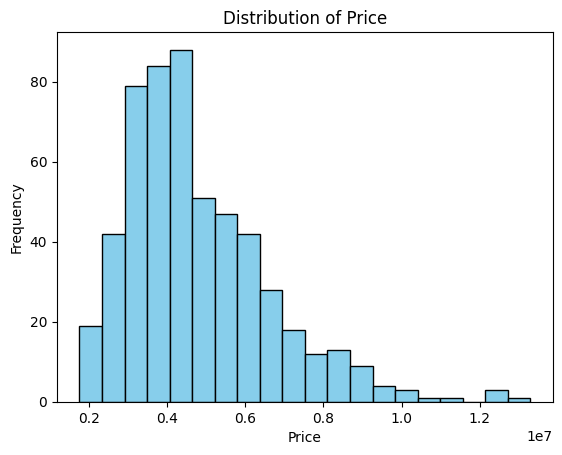

In [304]:
plt.hist(df["price"], bins = 20, color = "skyblue", edgecolor="black")
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [305]:
df["furnishingstatus"].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [306]:
df.groupby("furnishingstatus")["price"].mean().sort_values(ascending=False)

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

In [307]:
df.sort_values(by="area", ascending=False)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
125,5943000,15600,3,1,1,yes,no,no,no,yes,2,no,semi-furnished
10,9800000,13200,3,1,2,yes,no,yes,no,yes,2,yes,furnished
66,6930000,13200,2,1,1,yes,no,yes,yes,no,1,no,furnished
403,3500000,12944,3,1,1,yes,no,no,no,no,0,no,unfurnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,2240000,1950,3,1,1,no,no,no,yes,no,0,no,unfurnished
271,4340000,1905,5,1,2,no,no,yes,no,no,0,no,semi-furnished
527,2275000,1836,2,1,1,no,no,yes,no,no,0,no,semi-furnished
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished


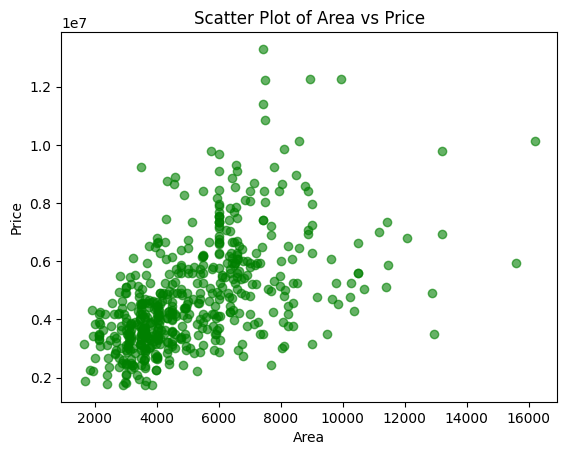

In [308]:
plt.scatter(df["area"],df["price"], color="green", alpha = 0.6)
plt.title("Scatter Plot of Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

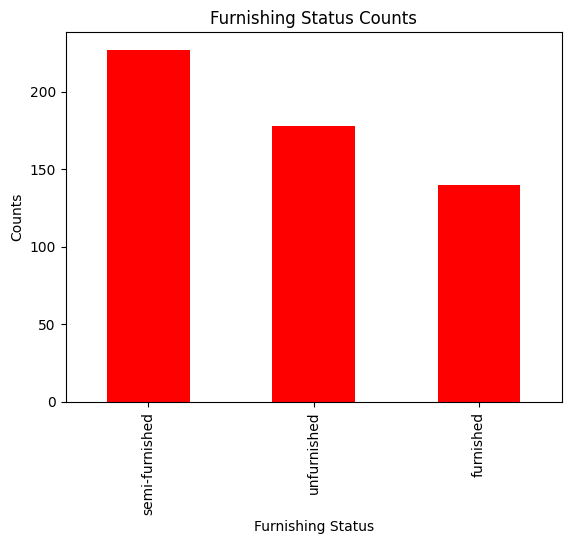

In [309]:
df["furnishingstatus"].value_counts().plot(kind="bar", color="red")
plt.title("Furnishing Status Counts")
plt.xlabel("Furnishing Status")
plt.ylabel("Counts")
plt.show()

In [310]:
df["mainroad"].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [311]:
df["hotwaterheating"].value_counts()

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

In [312]:
df["airconditioning"].value_counts()

airconditioning
no     373
yes    172
Name: count, dtype: int64

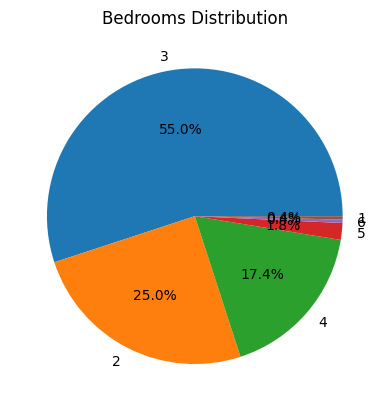

In [313]:
df["bedrooms"].value_counts().plot(kind="pie", autopct = "%1.1f%%")
plt.title("Bedrooms Distribution")
plt.ylabel("")
plt.show()

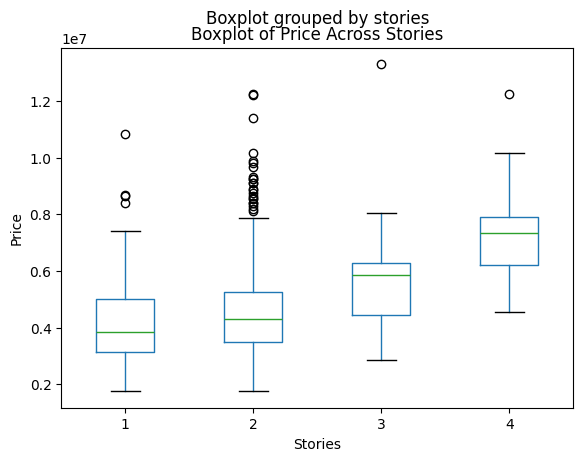

In [314]:
df.boxplot(column = "price", by="stories", grid=False)
plt.title("Boxplot of Price Across Stories")
plt.xlabel("Stories")
plt.ylabel("Price")
plt.show()

In [315]:
df.groupby("guestroom")["price"].mean()

guestroom
no     4.544546e+06
yes    5.792897e+06
Name: price, dtype: float64

In [316]:
df.groupby("basement")["area"].max()

basement
no     16200
yes    13200
Name: area, dtype: int64

In [317]:
df.groupby("airconditioning")["price"].median()

airconditioning
no     3885000.0
yes    5757500.0
Name: price, dtype: float64

In [318]:
df.groupby("mainroad")["price"].min()

mainroad
no     1750000
yes    1750000
Name: price, dtype: int64

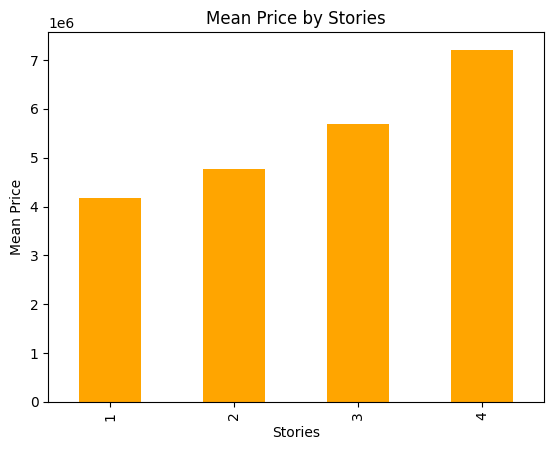

In [319]:
df.groupby("stories")["price"].mean().plot(kind="bar",color="orange")
plt.title("Mean Price by Stories")
plt.xlabel("Stories")
plt.ylabel("Mean Price")
plt.show()

Selecting columns for Model

In [320]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [321]:
from sklearn import preprocessing
labelencoder = preprocessing.LabelEncoder()
df["mainroad"] = labelencoder.fit_transform(df["mainroad"])
df["furnishingstatus"] = labelencoder.fit_transform(df["furnishingstatus"])

In [322]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,no,no,no,yes,2,yes,0
1,12250000,8960,4,4,4,1,no,no,no,yes,3,no,0
2,12250000,9960,3,2,2,1,no,yes,no,no,2,yes,1
3,12215000,7500,4,2,2,1,no,yes,no,yes,3,yes,0
4,11410000,7420,4,1,2,1,yes,yes,no,yes,2,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,no,yes,no,no,2,no,2
541,1767150,2400,3,1,1,0,no,no,no,no,0,no,1
542,1750000,3620,2,1,1,1,no,no,no,no,0,no,2
543,1750000,2910,3,1,1,0,no,no,no,no,0,no,0


In [323]:
y = df["price"]
X = df[["area", "bedrooms", "bathrooms", "mainroad", "furnishingstatus"]]

In [324]:
X

,area,bedrooms,bathrooms,mainroad,furnishingstatus
0,7420,4,2,1,0
1,8960,4,4,1,0
2,9960,3,2,1,1
3,7500,4,2,1,0
4,7420,4,1,1,0
...,...,...,...,...,...
540,3000,2,1,1,2
541,2400,3,1,0,1
542,3620,2,1,1,2
543,2910,3,1,0,0


In [325]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

#Splitting Data into test and train 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

In [326]:
#Fit & Transform Training data
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)

#Only transform Test data
scaled_X_test = scaler.transform(X_test)

In [327]:

def modelresults(predictions):
    print("Mean absolute error on model is {}".format(mean_absolute_error(y_test, predictions)))
    print("Root mean squared error on model is {}".format(np.sqrt(mean_squared_error(y_test,predictions))))



In [328]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(scaled_X_train, y_train)
predslr = lr.predict(scaled_X_test)
modelresults(predslr)


Mean absolute error on model is 725590.9641194972
Root mean squared error on model is 1003795.8283950682


Predicted vs Actual Values Scatter Plot

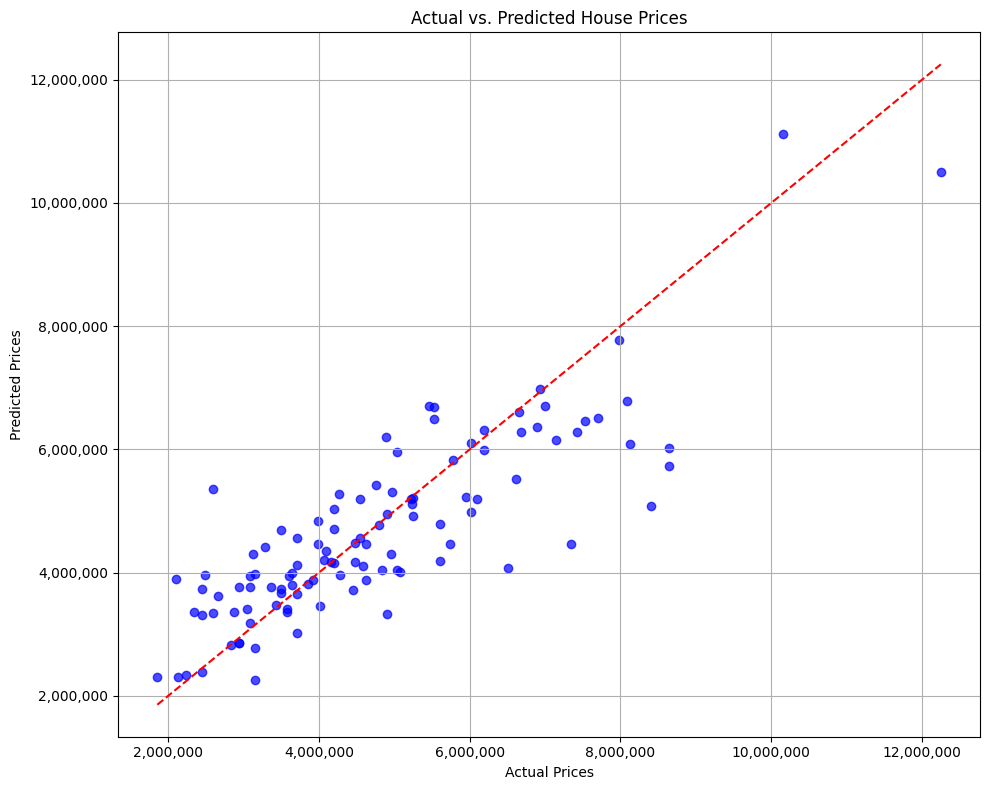

In [329]:
import matplotlib.ticker as ticker
plt.figure(figsize=(10, 8))
plt.scatter(y_test, predslr, alpha=0.7, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Perfect prediction line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))

# Format y-axis with commas for large numbers
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))

plt.tight_layout()
plt.show()


Residual Plot

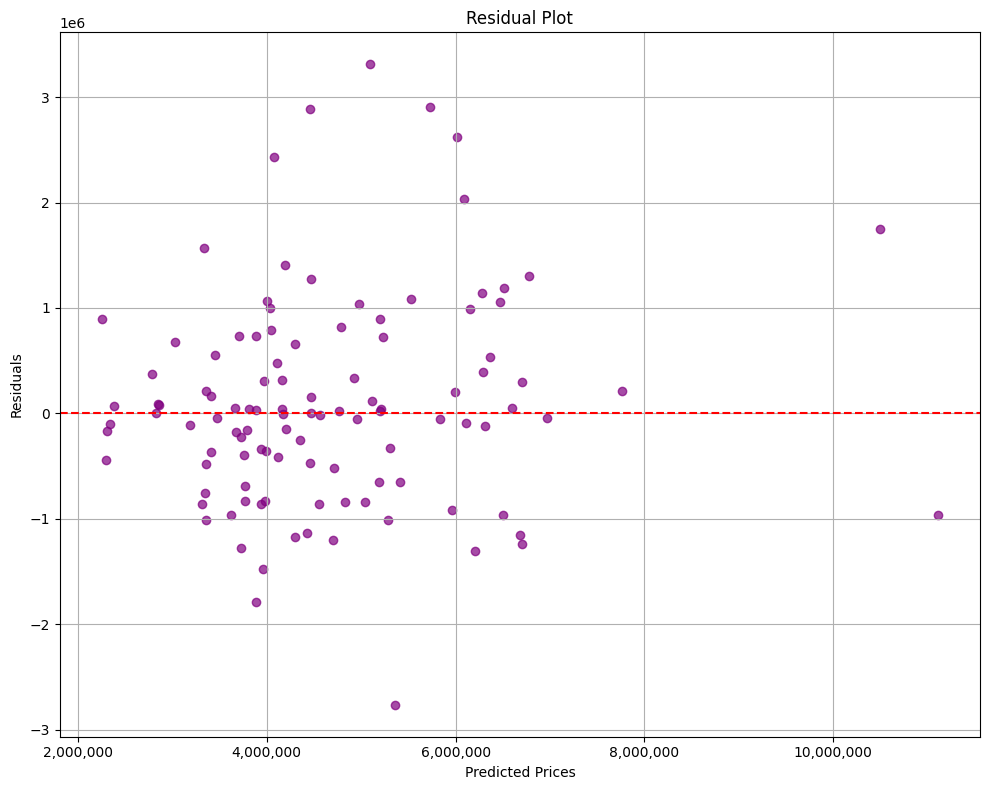

In [330]:
residuals = y_test - predslr

plt.figure(figsize=(10, 8))
plt.scatter(predslr, residuals, alpha=0.7, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))


plt.tight_layout()

plt.show()

Predict the Price of houses given certain parameters

In [331]:
new_house = {
    "area": 1200,          # Area in square feet
    "bedrooms": 3,         # Number of bedrooms
    "bathrooms": 2,        # Number of bathrooms
    "mainroad": 1,         # 1 for yes, 0 for no (binary)
    "furnishingstatus": 1  # 1 for furnished, 0 for unfurnished (binary)
}

# Convert the input into a pandas DataFrame
new_house_df = pd.DataFrame([new_house])

# Scale the new data using the same scaler that was fit on the training data
scaled_new_house = scaler.transform(new_house_df)

# Predict the price using the trained model
predicted_price = lr.predict(scaled_new_house)

# Output the predicted price
print(f"The predicted price for the house is: {predicted_price[0]:,.2f}")

The predicted price for the house is: 4,654,216.57


Creating a support vector model

In [332]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
svrmodel = SVR()

In [333]:
param_gridsvr = {"C" : [0.001, 0.01, 0.1, 0.5], 
                 "kernel" : ["linear", "rbf","poly"],
                 "gamma"  : ["scale","auto"],
                 "degree" : [2,3,4,5]}

In [334]:
gridsvr = GridSearchCV(svrmodel, param_gridsvr)

In [335]:
gridsvr.fit(scaled_X_train, y_train)

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5], 'degree': [2, 3, 4, 5],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']})

In [336]:
print("Best parameters for model is {}".format(gridsvr.best_params_))

Best parameters for model is {'C': 0.5, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}


In [337]:
predgridsvr = gridsvr.predict(scaled_X_test)

In [338]:
modelresults(predgridsvr)

Mean absolute error on model is 1434689.2108030205
Root mean squared error on model is 1909421.8402448632


In [339]:
from xgboost import XGBRegressor
xgb = XGBRegressor()

In [340]:
param_grid = {
    "n_estimators" : [50,100,500,1000,2000],
    "learning_rate" :[0.01,0.1,0.2,0.5],
    "max_depth" : [3,5,7,9]
}

In [341]:
grid_search = GridSearchCV(xgb, param_grid, cv = 3)
grid_search.fit(scaled_X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2, 0.5],
                         'max_depth': [3, 5, 7, 9],
                         'n_estimators': [50, 100, 500, 1000, 2000]})

In [342]:
grid_search.best_params_

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}

In [343]:
xgbpred = grid_search.predict(scaled_X_test)

In [344]:
modelresults(xgbpred)

Mean absolute error on model is 766388.1875
Root mean squared error on model is 1041272.0304550583
